In [1]:
!pip install kaggle

In [2]:
# configuring th epath of kaggle.json file

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Importing the Face Mask Dataset


In [3]:
# Api to fetch the datatset from kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:10<00:00, 15.6MB/s]



In [4]:
# extract the compressed dataset
from zipfile import ZipFile
dataset = "/content/face-mask-dataset.zip"

with ZipFile(dataset, 'r') as zip:
  zip.extractall()

print("data is extracted")

data is extracted


In [5]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data


Importing the dependencies

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [7]:
with_mask_files = os.listdir("/content/data/with_mask")

In [8]:
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_2559.jpg', 'with_mask_2684.jpg', 'with_mask_1386.jpg', 'with_mask_3432.jpg', 'with_mask_2356.jpg']
['with_mask_2266.jpg', 'with_mask_31.jpg', 'with_mask_140.jpg', 'with_mask_704.jpg', 'with_mask_1702.jpg']


In [9]:
without_mask_files = os.listdir("/content/data/without_mask")
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_3502.jpg', 'without_mask_1080.jpg', 'without_mask_1007.jpg', 'without_mask_3057.jpg', 'without_mask_1649.jpg']
['without_mask_590.jpg', 'without_mask_3495.jpg', 'without_mask_1040.jpg', 'without_mask_1084.jpg', 'without_mask_356.jpg']


In [10]:
print("Number of with mask images: ",len(with_mask_files))
print("Number of without mask images: ",len(without_mask_files))

Number of with mask images:  3725
Number of without mask images:  3828


Create Labels for the two class of Images


with mask ->1
without mask ->0

In [11]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [12]:
print(with_mask_labels[0:5])
print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [13]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [14]:
labels = with_mask_labels +without_mask_labels

print(len(labels))

print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [15]:
type(labels)

list

Displaying the images

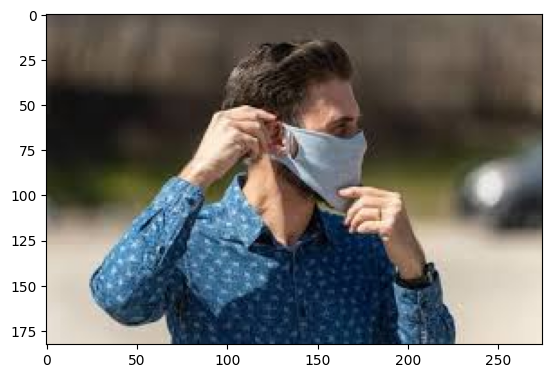

In [16]:
# displaying with mask images

img = mpimg.imread("/content/data/with_mask/with_mask_2590.jpg")
imgplot = plt.imshow(img)
plt.show()

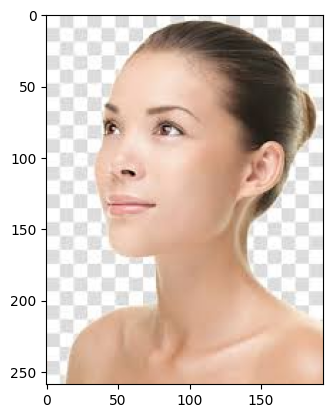

In [17]:
# displaying with mask images

img = mpimg.imread("/content/data/without_mask/without_mask_2925.jpg")
imgplot = plt.imshow(img)
plt.show()

Image processing

1. resize the images
2. Convert the images to numpy arrays

In [18]:
# convert images to numpy arrays

with_mask_path = "/content/data/with_mask/"

data = []

for img_file in with_mask_files:
  image = Image.open(with_mask_path+ img_file)
  image = image.resize((128,128))
  image = image.convert("RGB")
  image = np.array(image)

  data.append(image)


without_mask_path = "/content/data/without_mask/"

for img_file in without_mask_files:
  image = Image.open(without_mask_path+ img_file)
  image = image.resize((128,128))
  image = image.convert("RGB")
  image = np.array(image)

  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [19]:
len(data)

7553

In [20]:
type(data)

list

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[179, 179, 179],
        [ 28,  28,  28],
        [ 38,  38,  38],
        ...,
        [ 52,  52,  52],
        [ 52,  52,  52],
        [208, 208, 208]],

       [[127, 127, 127],
        [ 20,  20,  20],
        [ 42,  42,  42],
        ...,
        [ 44,  44,  44],
        [ 42,  42,  42],
        [143, 143, 143]],

       [[ 84,  84,  84],
        [ 29,  29,  29],
        [ 40,  40,  40],
        ...,
        [ 41,  41,  41],
        [ 40,  40,  40],
        [ 93,  93,  93]]], dtype=uint8)
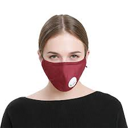

In [21]:
data[0]

In [22]:
# converting image list and label list to numpy array

X = np.array(data)
Y = np.array(labels)

In [23]:
type(X)
type(Y)

numpy.ndarray

Train Test Split

In [24]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [25]:
print(X_train.shape,X_test.shape)

(6042, 128, 128, 3) (1511, 128, 128, 3)


In [26]:
# scaling the data
X_train_scaled = X_train/255
X_test_scaled = X_test/255


## Building a Convolutional Neural Network (CNN)

In [27]:
import tensorflow as tf
from tensorflow import keras

In [28]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32,kernel_size=(3,3) ,activation="relu",input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64,kernel_size=(3,3) ,activation="relu"))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128,activation="relu"))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64,activation="relu"))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(num_of_classes ,activation="softmax"))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
# compile the neural network

model.compile(optimizer ="adam",
              loss="sparse_categorical_crossentropy",
              metrics=['acc'])

In [30]:
# training the neural network

history = model.fit(X_train_scaled,Y_train,validation_split=0.1,epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - acc: 0.7940 - loss: 0.4885 - val_acc: 0.8826 - val_loss: 0.2908
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.8817 - loss: 0.2956 - val_acc: 0.8777 - val_loss: 0.2647
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.8999 - loss: 0.2519 - val_acc: 0.9157 - val_loss: 0.2210
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9145 - loss: 0.2111 - val_acc: 0.9107 - val_loss: 0.2199
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9316 - loss: 0.1758 - val_acc: 0.9207 - val_loss: 0.2025


Model Evalution

In [31]:
loss,accuracy = model.evaluate(X_test_scaled,Y_test)
print("Test Accuracy = ",accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9246 - loss: 0.2090
Test Accuracy =  0.9245532751083374


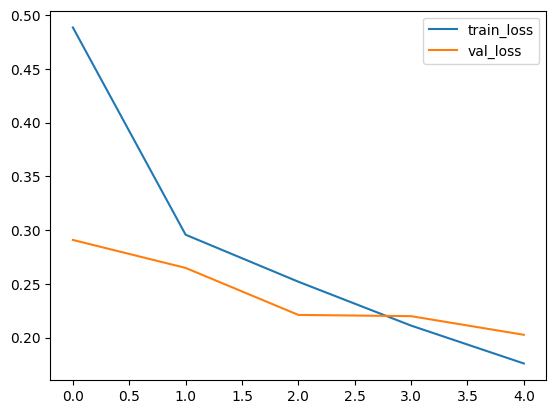

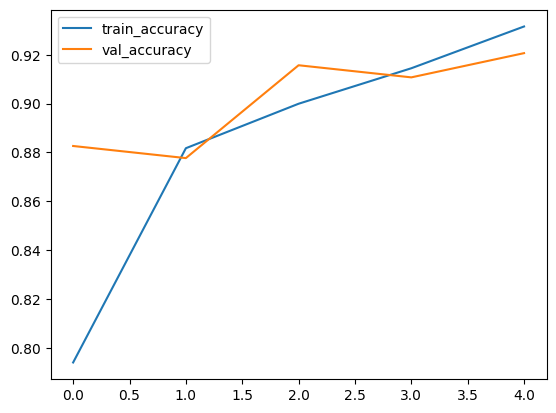

In [32]:
h = history

# plot the loss value
plt.plot(h.history['loss'],label="train_loss")
plt.plot(h.history['val_loss'],label="val_loss")
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'],label='train_accuracy')
plt.plot(h.history["val_acc"],label="val_accuracy")
plt.legend()
plt.show()

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


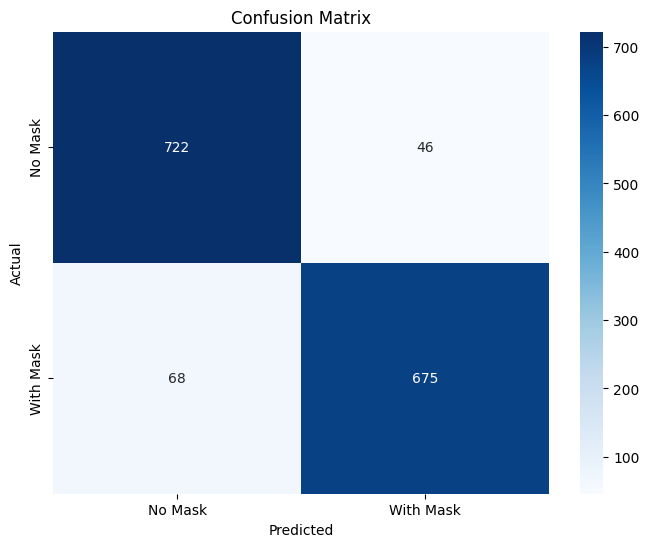

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

Y_pred = model.predict(X_test_scaled)
Y_pred_labels = [np.argmax(i) for i in Y_pred]

conf_matrix = confusion_matrix(Y_test, Y_pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Mask', 'With Mask'],
            yticklabels=['No Mask', 'With Mask'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## Predictive System

Path of the image to be predicted: /content/data/without_mask/without_mask_2925.jpg


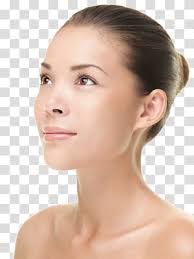

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[[0.98185575 0.01814426]]
0
The person is not wearing a mask


In [34]:
input_image_path = input("Path of the image to be predicted: ")

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_rgb = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)

input_image_resized = cv2.resize(input_image_rgb, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled,[1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label ==1:
  print("The person is wearing a mask")
else:
  print("The person is not wearing a mask")

In [35]:
model.save("face_mask_detector.keras")